In [118]:
import pandas as pd

df = pd.read_csv("/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/data/raw/uncleaned-ds-jobs-6992efeeb7cba766418597.csv")


In [119]:
import numpy as np
df = df.replace(-1, np.nan)
df = df.replace("-1", np.nan)


In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    str    
 2   Salary Estimate    672 non-null    str    
 3   Job Description    672 non-null    str    
 4   Rating             622 non-null    float64
 5   Company Name       672 non-null    str    
 6   Location           672 non-null    str    
 7   Headquarters       641 non-null    str    
 8   Size               645 non-null    str    
 9   Founded            554 non-null    float64
 10  Type of ownership  645 non-null    str    
 11  Industry           601 non-null    str    
 12  Sector             601 non-null    str    
 13  Revenue            645 non-null    str    
 14  Competitors        171 non-null    str    
dtypes: float64(2), int64(1), str(12)
memory usage: 78.9 KB


In [121]:

import re
title= df["Job Title"]

def job_title(title):

    title = title.str.lower()
    title = title.str.replace("sr", "senior", regex=False)
    title = title.str.replace("jr", "junior", regex=False)
    title = title.str.replace("ml", "machine learning", regex=False)
    title = title.str.replace("scientistsmachine", "scientists machine", regex=False)
    title = title.str.replace("  ", "scientists machine", regex=False)
    title = title.str.replace(r"[^\w\s]", "", regex=True)
    return title

df["Job Title"]=job_title(df["Job Title"]) 
    

In [122]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

columns = ["Company Name", "Revenue", "Type of ownership", "Job Description", "Job Title",
           "Rating", "Location", "Headquarters", "Size", "Founded", "Type of ownership",
           "Industry", "Sector", "Revenue", "Competitors"]

stop_words = set(stopwords.words("english"))

for col in columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.lower()
        .str.replace("^&", "", regex=False)
        .str.replace("'", "", regex=False)
        .str.replace("K", "", regex=False)
        .str.replace("\n", "", regex=False)
        .str.replace("/", "", regex=False)
        .str.replace("&", "", regex=False)
        .str.replace(")", "", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("#", "", regex=False)
        .str.replace(":", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.replace("_", "", regex=False)
        .str.replace("*", "", regex=False)
        .str.replace("+", "", regex=False)
        .str.replace("]", "", regex=False)
        .str.replace("[", "", regex=False)
        .str.replace("<", "", regex=False)
        .str.replace(">", "", regex=False)
        .str.replace("!", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("?", "", regex=False)
        
    )

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/miriambenali/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [123]:

df["Salary Estimate"]= (
    df["Salary Estimate"]
    .str.replace("Glassdoor est.", "", regex=False)
    .str.replace("Employer est.", "", regex=False)
    .str.replace("()", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace("K", "", regex=False)
    
)

In [124]:
df["Size"]= (
    df["Size"]
    .str.replace("to", "-", regex=False)
    .str.replace("employees", "", regex=False)
    
)

In [125]:
df.head(5)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,senior data scientist,137-171,descriptionthe senior data scientist is respon...,3.1,healthfirst3.1,"new york, ny","new york, ny",1001 - 5000,1993.0,nonprofit organization,insurance carriers,insurance,unknown nonapplicable,"emblemhealth, unitedhealth group, aetna"
1,1,data scientist,137-171,"secure our nation, ignite your futurejoin the ...",4.2,mantech4.2,"chantilly, va","herndon, va",5001 - 10000,1968.0,company public,research development,business services,1 to 2 billion usd,NaN
2,2,data scientist,137-171,overviewanalysis group is one of the largest i...,3.8,analysis group3.8,"boston, ma","boston, ma",1001 - 5000,1981.0,private practice firm,consulting,business services,100 to 500 million usd,NaN
3,3,data scientist,137-171,job descriptiondo you have a passion for data ...,3.5,inficon3.5,"newton, ma","bad ragaz, switzerland",501 - 1000,2000.0,company public,electrical electronic manufacturing,manufacturing,100 to 500 million usd,"mks instruments, pfeiffer vacuum, agilent tech..."
4,4,data scientist,137-171,data scientistaffinity solutions marketing cl...,2.9,affinity solutions2.9,"new york, ny","new york, ny",51 - 200,1998.0,company private,advertising marketing,business services,unknown nonapplicable,"commerce signals, cardlytics, yodlee"


In [126]:
#calcule mean salary
def compute_mean_salary(salary):
    min_salary, max_salary = salary.split("-")

    min_salary = float(min_salary)
    max_salary = float(max_salary)

    return (min_salary + max_salary) / 2

df["mean_salary"] = df["Salary Estimate"].apply(compute_mean_salary)

df["mean_salary"] = df["mean_salary"] * 1000


In [127]:
#calcule mean revenue
def compute_mean_range(value):
    
    if pd.isna(value):
        return np.nan
    
    # vérifier qu'il y a bien "-"
    if "-" in value:
        min_val, max_val = value.split("-")
        min_val = float(min_val.strip())
        max_val = float(max_val.strip())
        return (min_val + max_val) / 2
    
    else:
        # cas comme "10000+" ou "Unknown"
        value = value.replace("+", "").strip()
        
        try:
            return float(value)
        except:
            return np.nan
        
df["mean_size"] = df["Size"].apply(compute_mean_range)

In [128]:
import numpy as np
import pandas as pd
import re

def compute_revenue(value):
    
    if pd.isna(value):
        return np.nan
    
    value = value.lower()
    
    # gérer unknown
    if "unknown" in value:
        return np.nan
    
    # détecter l’unité
    multiplier = 1
    
    if "billion" in value:
        multiplier = 1_000_000_000
    elif "million" in value:
        multiplier = 1_000_000
    
    # extraire les nombres
    numbers = re.findall(r"\d+\.?\d*", value)
    
    if len(numbers) == 2:
        min_val = float(numbers[0])
        max_val = float(numbers[1])
        return ((min_val + max_val) / 2) * multiplier
    
    elif len(numbers) == 1:
        return float(numbers[0]) * multiplier
    
    else:
        return np.nan

In [129]:
def extract_seniority(title):
    title= title.lower()
    if "senior" in title:
        return "senior"
    elif "junior" in title:
        return "junior"
    elif "lead" in title:
        return "lead"
    elif "early" in title:
        return "early"
    elif "principal" in title:
        return "principal"
    else:
        return "mid"
    
df["seniority"]= df["Job Title"].apply(extract_seniority)

In [130]:
def extract_role(title):
    title=  title.lower()

    if "machine learning" in title:
        return "ml engineer"
    elif "data scientist" in title:
        return "data scientist"
    elif "data analyst" in title:
        return "data analyst"
    elif "data engineer" in title:
        return "data engineer"
    else:
        return "other"
    

df["job_role"] = df["Job Title"].apply(extract_role)

In [131]:
KNOWN_SKILLS = ["Python", "SQL", "Azure", "Docker", "Machine Learning", "MLops", "deployement"]

def extract_skills(discription):
    found=[]
    for skill in KNOWN_SKILLS:
        if skill.lower() in discription.lower():
            found.append(skill)
    return found

df["job_skills"] = df["Job Description"].apply(extract_skills)

#transformer en str 
df["skills"] = df["job_skills"].apply(lambda x: " ".join(x) )


In [132]:
def clean_company_name(company_name):
    return re.sub(r"\d+\.\d+$", "", company_name).strip()

df["Company Name"] = df["Company Name"].apply(clean_company_name)

In [133]:
df["mean_revenue"] = df["Revenue"].apply(compute_revenue)
df["log_revenue"] = np.log1p(df["mean_revenue"])
#Le revenue était skewed avec des valeurs extrêmes, donc j’ai utilisé le log pour stabiliser la variance et aider le modèle à mieux apprendre

<Axes: >

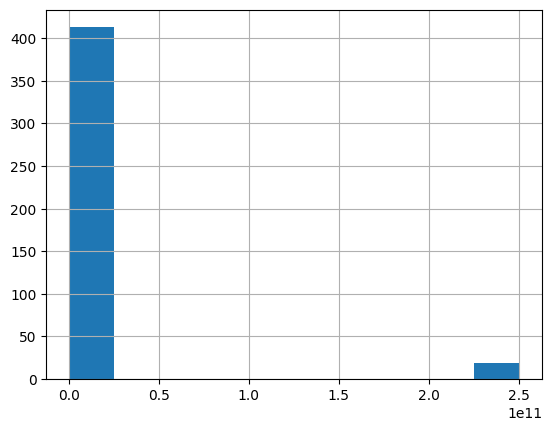

In [134]:
df["mean_revenue"].hist()

<Axes: >

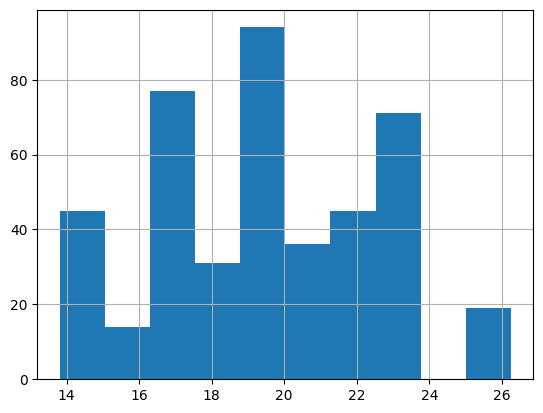

In [135]:
df["log_revenue"].hist()

In [136]:
#feature engineering pour la column Founded # année actuelle moins l'année de fondation
df["Founded"]=pd.to_numeric(df["Founded"], errors= 'coerce')  # les valeurs non numériques deviennent NaN

df["Founded"]= df["Founded"].fillna(df["Founded"].median()) ## remplir les NaN avec la médiane

df['company_age'] = 2026 - df['Founded'] 

In [137]:
#feature engineering pour la column Founded # année actuelle moins l'année de fondation
df['size_category'] = pd.cut(df['mean_size'],
                             bins=[0, 500, 5000, 20000],
                             labels=['small', 'medium', 'large'])

In [138]:
df.head(5)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,mean_salary,mean_size,seniority,job_role,job_skills,skills,mean_revenue,log_revenue,company_age,size_category
0,0,senior data scientist,137-171,descriptionthe senior data scientist is respon...,3.1,healthfirst,"new york, ny","new york, ny",1001 - 5000,1993.0,...,154000.0,3000.5,senior,data scientist,"[Azure, Machine Learning]",Azure Machine Learning,NaN,NaN,33.0,medium
1,1,data scientist,137-171,"secure our nation, ignite your futurejoin the ...",4.2,mantech,"chantilly, va","herndon, va",5001 - 10000,1968.0,...,154000.0,7500.5,mid,data scientist,"[SQL, Machine Learning]",SQL Machine Learning,1.500000e+09,21.128731,58.0,large
2,2,data scientist,137-171,overviewanalysis group is one of the largest i...,3.8,analysis group,"boston, ma","boston, ma",1001 - 5000,1981.0,...,154000.0,3000.5,mid,data scientist,"[Python, Machine Learning]",Python Machine Learning,3.000000e+08,19.519293,45.0,medium
3,3,data scientist,137-171,job descriptiondo you have a passion for data ...,3.5,inficon,"newton, ma","bad ragaz, switzerland",501 - 1000,2000.0,...,154000.0,750.5,mid,data scientist,"[Python, SQL, Machine Learning]",Python SQL Machine Learning,3.000000e+08,19.519293,26.0,medium
4,4,data scientist,137-171,data scientistaffinity solutions marketing cl...,2.9,affinity solutions,"new york, ny","new york, ny",51 - 200,1998.0,...,154000.0,125.5,mid,data scientist,"[Python, SQL, Machine Learning]",Python SQL Machine Learning,NaN,NaN,28.0,small


In [144]:
df.isnull().sum()

index                  0
Job Title              0
Salary Estimate        0
Job Description        0
Rating                50
Company Name           0
Location               0
Headquarters          31
Size                  27
Founded                0
Type of ownership     27
Industry              71
Sector                71
Revenue               27
Competitors          501
mean_salary            0
mean_size             44
seniority              0
job_role               0
job_skills             0
skills                 0
mean_revenue         240
log_revenue          240
company_age            0
size_category         44
dtype: int64

In [145]:
numeric_cols = ['Rating', 'Founded', 'mean_salary']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [146]:
# Pour les colonnes catégorielles
df['Type of ownership'] = df['Type of ownership'].fillna(df['Type of ownership'].mode()[0])
df['Revenue'] = df['Revenue'].fillna(df['Revenue'].mode()[0])
df['Headquarters'] = df['Headquarters'].fillna(df['Headquarters'].mode()[0])


# Pour les colonnes numériques
df['mean_size'] = df['mean_size'].fillna(df['mean_size'].median())
df['mean_revenue'] = df['mean_revenue'].fillna(df['mean_revenue'].median())
df['log_revenue'] = df['log_revenue'].fillna(np.log1p(df['mean_revenue']))


In [147]:
# Colonnes numériques
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Founded'] = df['Founded'].fillna(df['Founded'].median())
df['Size'] = df['Size'].fillna(df['Size'].mode()[0])

# Colonnes catégorielles
df['Industry'] = df['Industry'].fillna('Unknown')
df['Sector'] = df['Sector'].fillna('Unknown')
df['Headquarters'] = df['Headquarters'].fillna(df['Location'])  # si ça fait sens


df['size_category'] = df['size_category'].astype(str)
df['size_category'] = df['size_category'].fillna('Unknown')

In [148]:
df.isnull().sum()

index                  0
Job Title              0
Salary Estimate        0
Job Description        0
Rating                 0
Company Name           0
Location               0
Headquarters           0
Size                   0
Founded                0
Type of ownership      0
Industry               0
Sector                 0
Revenue                0
Competitors          501
mean_salary            0
mean_size              0
seniority              0
job_role               0
job_skills             0
skills                 0
mean_revenue           0
log_revenue            0
company_age            0
size_category          0
dtype: int64

In [149]:
df[["mean_salary", "log_revenue", "mean_size", "Rating", "company_age"]].corr()

,mean_salary,log_revenue,mean_size,Rating,company_age
mean_salary,1.000000,0.051981,-0.000159,-0.001456,-0.017569
log_revenue,0.051981,1.000000,0.627722,-0.189140,0.494649
mean_size,-0.000159,0.627722,1.000000,-0.209096,0.620685
Rating,-0.001456,-0.189140,-0.209096,1.000000,-0.175828
company_age,-0.017569,0.494649,0.620685,-0.175828,1.000000


Les variables numériques ont une corrélation faible avec le salaire, donc il faut enrichir le modèle avec dautres features

In [150]:
df.head(5)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,mean_salary,mean_size,seniority,job_role,job_skills,skills,mean_revenue,log_revenue,company_age,size_category
0,0,senior data scientist,137-171,descriptionthe senior data scientist is respon...,3.1,healthfirst,"new york, ny","new york, ny",1001 - 5000,1993.0,...,154000.0,3000.5,senior,data scientist,"[Azure, Machine Learning]",Azure Machine Learning,3.000000e+08,19.519293,33.0,medium
1,1,data scientist,137-171,"secure our nation, ignite your futurejoin the ...",4.2,mantech,"chantilly, va","herndon, va",5001 - 10000,1968.0,...,154000.0,7500.5,mid,data scientist,"[SQL, Machine Learning]",SQL Machine Learning,1.500000e+09,21.128731,58.0,large
2,2,data scientist,137-171,overviewanalysis group is one of the largest i...,3.8,analysis group,"boston, ma","boston, ma",1001 - 5000,1981.0,...,154000.0,3000.5,mid,data scientist,"[Python, Machine Learning]",Python Machine Learning,3.000000e+08,19.519293,45.0,medium
3,3,data scientist,137-171,job descriptiondo you have a passion for data ...,3.5,inficon,"newton, ma","bad ragaz, switzerland",501 - 1000,2000.0,...,154000.0,750.5,mid,data scientist,"[Python, SQL, Machine Learning]",Python SQL Machine Learning,3.000000e+08,19.519293,26.0,medium
4,4,data scientist,137-171,data scientistaffinity solutions marketing cl...,2.9,affinity solutions,"new york, ny","new york, ny",51 - 200,1998.0,...,154000.0,125.5,mid,data scientist,"[Python, SQL, Machine Learning]",Python SQL Machine Learning,3.000000e+08,19.519293,28.0,small


In [151]:
cleaned_data = df.drop(columns=["index", "Salary Estimate", "Size", "Revenue", "mean_revenue", "Location", "Competitors", "Headquarters", "Founded", "mean_size", "Type of ownership","Job Title","Job Description", "job_skills"])

In [152]:
cleaned_data.head(5)

,Rating,Company Name,Industry,Sector,mean_salary,seniority,job_role,skills,log_revenue,company_age,size_category
0,3.1,healthfirst,insurance carriers,insurance,154000.0,senior,data scientist,Azure Machine Learning,19.519293,33.0,medium
1,4.2,mantech,research development,business services,154000.0,mid,data scientist,SQL Machine Learning,21.128731,58.0,large
2,3.8,analysis group,consulting,business services,154000.0,mid,data scientist,Python Machine Learning,19.519293,45.0,medium
3,3.5,inficon,electrical electronic manufacturing,manufacturing,154000.0,mid,data scientist,Python SQL Machine Learning,19.519293,26.0,medium
4,2.9,affinity solutions,advertising marketing,business services,154000.0,mid,data scientist,Python SQL Machine Learning,19.519293,28.0,small


In [153]:
path = "/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/data/cleaned_data/cleaned_data.csv"

cleaned_data.to_csv(path, index=False)